# Working with complicated dataset

## Your name: Michael Hamaty

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"
df_og = pd.read_csv(data)
df_og


,# blastp,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,# Iteration: 0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,# Query: YP_220550.1 NADH dehydrogenase subuni...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# RID: 9SW3UNUT015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# Database: nr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Fields: query acc.ver, subject acc.ver, % id...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,YP_220550.1,ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,"17,348",6,NaN
102,YP_220550.1,ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,"7,105",19,NaN
103,YP_220550.1,YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,"18,940",37,NaN
104,YP_220550.1,YP_009414363.1,85.174,317.0,47.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,"18,762",5,NaN


In [13]:
#I am just going to use the names directly taken from the # Fields becasue I dont know how to do it otherwise, lol
col_names = ["query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches", "gap opens", "q. start", "q. end", "s. start", "s. end",
            "evalue", "bit score", "% positives", "query/sbjct frames", 
             "bonds", "publications"]
#we still have all the lines that begin with #, so we can tell pandas to skip over it
df = pd.read_csv(data, comment="#", names=col_names)
#drop first column acc.ver and use set_index
df = df.drop(columns=["query acc.ver"]).set_index("subject acc.ver")
df


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,query/sbjct frames,bonds,publications
subject acc.ver,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"1,487",9,NaN
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,"17,947",47,NaN
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,"12,106",13,NaN
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,"2,319",41,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,"17,348",6,NaN
ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,"7,105",19,NaN
YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,"18,940",37,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, nan to AGS12808.1
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   % identity          100 non-null    float64
 1   alignment length    100 non-null    float64
 2   mismatches          100 non-null    float64
 3   gap opens           100 non-null    float64
 4   q. start            100 non-null    float64
 5   q. end              100 non-null    float64
 6   s. start            100 non-null    float64
 7   s. end              100 non-null    float64
 8   evalue              100 non-null    float64
 9   bit score           100 non-null    float64
 10  % positives         100 non-null    float64
 11  query/sbjct frames  100 non-null    object 
 12  bonds               100 non-null    object 
 13  publications        1 non-null      object 
dtypes: float64(11), object(3)
memory usage: 11.8+ KB


Dataframe looks good now, however, the publications column contains only 1 non-null and the Dtype is object. The next question asks for avg publications, so I dont think we can really get that value

In [24]:
#I litterally cannot figure out why bonds is an object datatype
df = df.dropna(how='all') #drop rows that are completely empty
#comnvert to numeric so we can use boolean expresions
df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")


/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_89955/2227647663.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")
/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_89955/2227647663.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["publications"] = pd.to_numeric(df["publications"], errors="coerce")


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   % identity          100 non-null    float64
 1   alignment length    100 non-null    float64
 2   mismatches          100 non-null    float64
 3   gap opens           100 non-null    float64
 4   q. start            100 non-null    float64
 5   q. end              100 non-null    float64
 6   s. start            100 non-null    float64
 7   s. end              100 non-null    float64
 8   evalue              100 non-null    float64
 9   bit score           100 non-null    float64
 10  % positives         100 non-null    float64
 11  query/sbjct frames  100 non-null    object 
 12  bonds               97 non-null     float64
 13  publications        0 non-null      float64
dtypes: float64(13), object(1)
memory usage: 11.7+ KB


YESSSSSSS VERY GOOD

### Question 2
What is the average number of publications?

There are two main ways that are both very simple to do this now that we converted to a float type. Still is litterally all NaN vaules though

In [28]:
df["publications"].mean()


nan

In [ ]:
df["publications"].describe()

count     1
unique    1
top        
freq      1
Name: publications, dtype: object

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [ ]:
# df = df.drop(columns=["query/sbjct frames"])
# df["query/sbjct frames"] = pd.to_numeric(df["query/sbjct frames"], errors="coerce")
#nothing is appearing
df[df["bonds"] > 15000]

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

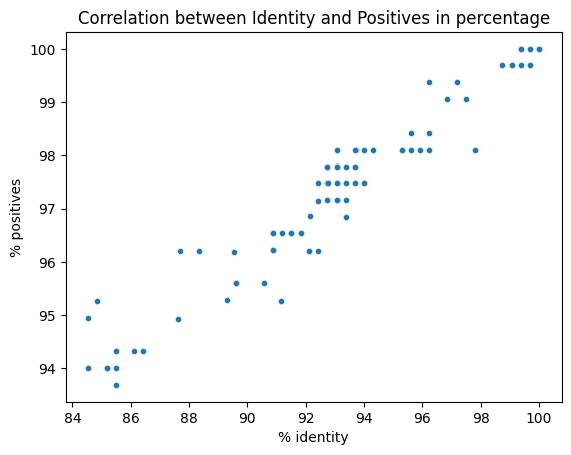

In [39]:

sns.scatterplot(data=df, x="% identity", y="% positives", s=20)
plt.title("Correlation between Identity and Positives in percentage")
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [ ]:
# #before merging you have to reset the index back to a regular column
# protein_df = pd.read_csv("https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv")
# #pd.merge fucntions like a SQL join with left and right sides to join on.
# #witht he reset index we join left on the subject acc.ver column and right on the protein column
# #and we want to keep all the rows in the left dataframe so we use how="left"
# merged_df = pd.merge(df.reset_index(),protein_df, left_on="subject acc.ver", right_on="Protein", how="left")
# #after gettign merged we have overlapping values, like the center part of a venn diagram, and we drop them
# merged_df = merged_df.drop(columns=["Protein"]).set_index("subject acc.ver")

In [45]:
merged_df

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Unnamed: 0,Source
subject acc.ver,,,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,9.0,NaN,0.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,47.0,NaN,NaN,NaN
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,13.0,NaN,2.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,41.0,NaN,NaN,NaN
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,6.0,NaN,NaN,NaN
ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,19.0,NaN,NaN,NaN
YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,37.0,NaN,97.0,GenPept


We see that the protein column is labeled as Unnamed 0, so lets fix that and source should be protein source. Unnamed 0 is the original df

In [ ]:
#Lets try this again clean because I cant figure out the error
#lets 
Protein_data = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(Protein_data)
#we drop the unnamed column becasue it doesnt belong here
df = df.drop(columns=["Unnamed: 0"], errors="ignore") #because it ran with errors=ignire and didnt do anythig, I know the the og column doesnt exist
#lets make a variable to reset the index of og df
reset_df  = df.reset_index()
#now we do the same merged stuff from earlier
merged_df = pd.merge(reset_df,protein_df, left_on="subject acc.ver", right_on="Protein", how="left")
merged_df = (merged_df.drop(columns=["Protein"]).rename(columns={"Source": "Protein source"}).set_index("subject acc.ver"))
merged_df


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Unnamed: 0,Protein source
subject acc.ver,,,,,,,,,,,,,,,
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,9.0,NaN,0.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,47.0,NaN,NaN,NaN
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,13.0,NaN,2.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,41.0,NaN,NaN,NaN
AHG32084.1,99.371,318.0,2.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,3.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ABX45285.1,92.767,318.0,23.0,0.0,1.0,318.0,1.0,318.0,0.0,551.0,97.48,6.0,NaN,NaN,NaN
ASP44815.1,93.375,317.0,21.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,96.85,19.0,NaN,NaN,NaN
YP_009414156.1,84.543,317.0,49.0,0.0,1.0,317.0,1.0,317.0,0.0,551.0,94.01,37.0,NaN,97.0,GenPept
